# Convolutions

In this lab, we'll look in detail at convolutions and how they can be used to process images.

### Reading and opening images

We'll use the `skimage` library to read and process images. It's a library dedicated to image processing, which is part of the `scikit-learn` family.

In [90]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import skimage

sample image shape:  (400, 600, 3)


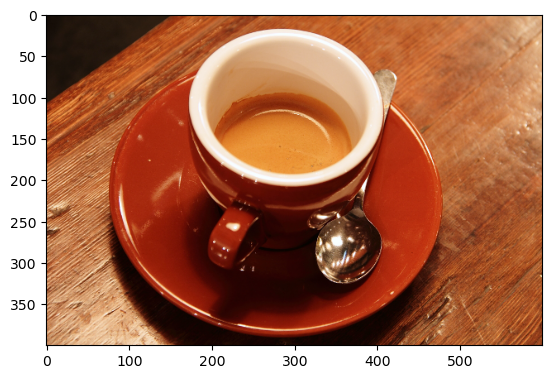

In [91]:
sample_image = skimage.data.coffee()

size = sample_image.shape
print("sample image shape: ", sample_image.shape)

plt.imshow(sample_image.astype('uint8'));

### A simple convolution filter

Before we start working on training any models, let's look at applying a convolution filter to an image. We'll use the `Conv2D` layer from Keras to do this.

In [92]:
from tensorflow.keras.layers import Conv2D

In [93]:
conv = Conv2D(filters=3, kernel_size=(5, 5), padding="same")

Remember: in Keras, `None` is used as a marker for tensor dimensions with dynamic size. In this case `batch_size`, `width` and `height` are all dynamic: they can depend on the input. This is a neat feature of convolutional neural networks: the same model can be used to process images of any size, because all we have to do is slide the convolutional filter across the image as much as necessary.

In [94]:
sample_image.shape

(400, 600, 3)

In [95]:
img_in = np.expand_dims(sample_image, 0).astype(float)
img_in.shape

(1, 400, 600, 3)

In [96]:
img_out = conv(img_in) # Apply the convolutional filter

The output is a tensorflow Eager Tensor - a special data structure that is used to represent the result of operations in TensorFlow. It is not a numpy array, but it can be converted to one using the `.numpy()` method:

In [97]:
np_img_out = img_out[0].numpy()
print(type(np_img_out))
print(np_img_out.shape)

<class 'numpy.ndarray'>
(400, 600, 3)


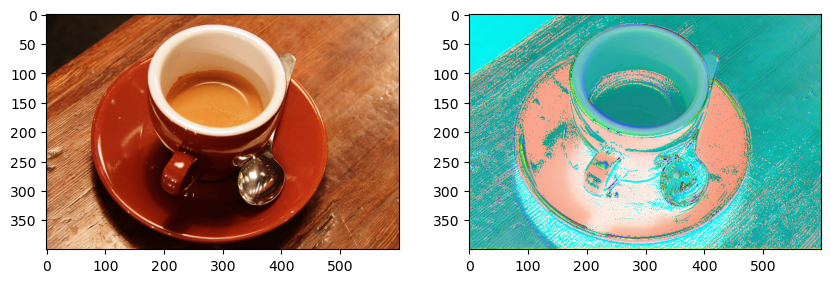

In [98]:
fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(10, 5))
ax0.imshow(sample_image.astype('uint8'))
ax1.imshow(np_img_out.astype('uint8'));

As we can see, our convolutional filter was initialized randomly, so our output doesn't contain any specific meaning. Each pixel is a random combination of the pixels in the input image, in a 5x5 window.

Let's instead take a look at a convolutional feature with a clear purpose. We can build a kernel ourselves, by defining a function which will be passed to `Conv2D` Layer.
We'll create an array with 1/25 for filters, with each channel seperated. Before you move to the next cell, can you guess what this filter will do?

In [99]:
def my_kernel(shape=(5, 5, 3, 3), dtype=None):
    array = np.zeros(shape=shape, dtype="float32")
    array[:, :, 0, 0] = 1 / 25
    array[:, :, 1, 1] = 1 / 25
    array[:, :, 2, 2] = 1 / 25
    return array

Now we can use this function to initialize a `Conv2D` layer:

In [100]:
conv = Conv2D(filters=3, kernel_size=(5, 5), padding="same", kernel_initializer=my_kernel)

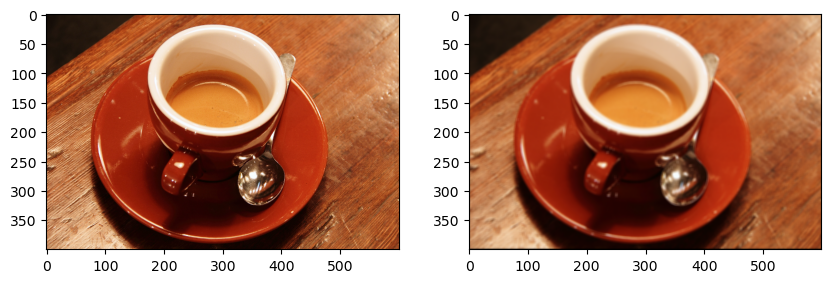

In [101]:
fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(10, 5))
ax0.imshow(img_in[0].astype('uint8'))

img_out = conv(img_in)
np_img_out = img_out[0].numpy()
ax1.imshow(np_img_out.astype('uint8'));

Hopefully you can tell what this filter does!

**Exercise**
- There are a number of settings when we define our Conv2D layer. Try changing the following parameters to get a sense of how they impact the result:
- kernel_size: try different sizes
- padding: try 'valid' instead of 'same' (hint: this may change the size of the output)

In [102]:
# convolutional layer:
from tensorflow.keras.layers import Conv2D

conv = Conv2D(filters=3, kernel_size=(5, 5), padding="same")


In [103]:
# Try experimenting with: 1. kernel_size 2. padding A (28x28) 
# image with a (5x5) kernel and 'valid' padding becomes (24x24).
# Small filter, same padding
Conv2D(filters=3, kernel_size=(3, 3), padding="same")
# Large filter, same padding
Conv2D(filters=3, kernel_size=(7, 7), padding="same")
# Conv2D(filters=3, kernel_size=(5, 5), padding="valid")
Conv2D(filters=3, kernel_size=(5, 5), padding="valid")


Conv2D(filters=3, kernel_size=(5, 5), padding="valid")




<Conv2D name=conv2d_24, built=False>

### Working on edge detection on Grayscale image

Using a grayscale image, let's build an "edge detector" using a convolutional filter. Some filters pre-date the deep learning era and are still used today. For example, the Sobel filter is used to detect edges in images. These easy-to-compute filters were used in the early days of computer vision and are still useful now.

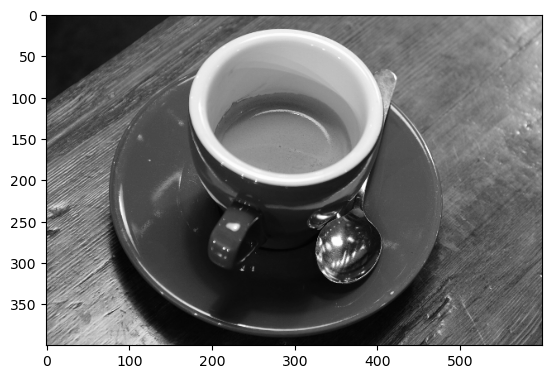

In [104]:
# convert image to greyscale
grey_sample_image = sample_image.mean(axis=2)

# add the channel dimension even if it's only one channel so
# to be consistent with Keras expectations.
grey_sample_image = grey_sample_image[:, :, np.newaxis]

# matplotlib does not like the extra dim for the color channel
# when plotting gray-level images. Let's use squeeze:
plt.imshow(np.squeeze(grey_sample_image.astype(np.uint8)),
           cmap=plt.cm.gray);

**Exercise**
- Build an edge detector using `Conv2D` on greyscale image by defining the kernel inside `my_kernel`.
- You may experiment with several kernels to find a way to detect edges. The following article contains specific examples of kernels that you can use:
- https://en.wikipedia.org/wiki/Kernel_(image_processing)
- Try different kernels and see the impact on the output.

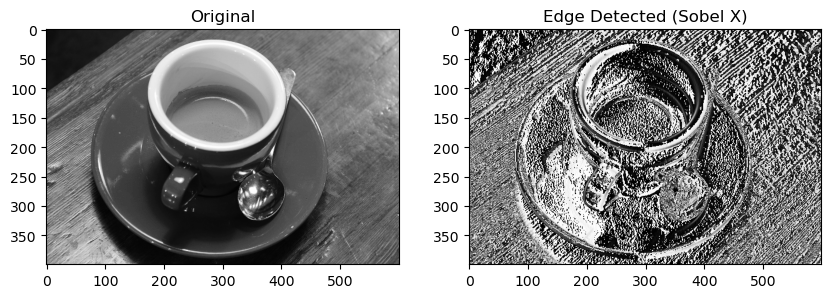

In [105]:
import numpy as np
from tensorflow.keras.initializers import Initializer

class SobelXKernel(Initializer):
    def __call__(self, shape=(3, 3, 1, 1), dtype=None):
        # Sobel X edge detector kernel
        kernel = np.array([
            [-1, 0, 1],
            [-2, 0, 2],
            [-1, 0, 1]
        ], dtype=np.float32)
        kernel = kernel.reshape((3, 3, 1, 1))  # (H, W, in_channels, out_channels)
        return kernel

# Create Conv2D layer with custom kernel
conv = Conv2D(filters=1, kernel_size=(3, 3), padding="same", kernel_initializer=SobelXKernel())

# Apply to input image
img_in = np.expand_dims(grey_sample_image, 0)  # Add batch dimension
img_out = conv(img_in)
np_img_out = img_out[0].numpy()  # Remove batch dimension

# Plot input vs output
fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(10, 5))
ax0.imshow(np.squeeze(grey_sample_image.astype(np.uint8)), cmap='gray')
ax0.set_title("Original")
ax1.imshow(np_img_out.astype(np.uint8), cmap='gray')
ax1.set_title("Edge Detected (Sobel X)")
plt.show()


### Pooling and strides with convolutions

**Exercise**
- Use `MaxPool2D` to apply a 2x2 max pool with strides 2 to the image. What is the impact on the shape of the image?
- Use `AvgPool2D` to apply an average pooling.
- Is it possible to compute a max pooling and an average pooling with well chosen kernels?

In [106]:
#  1. Apply MaxPool2D (2×2, stride=2)

from tensorflow.keras.layers import MaxPool2D

# Define max pooling layer
max_pool = MaxPool2D(pool_size=(2, 2), strides=2)

# Apply to image (assuming shape: [1, H, W, C])
pooled_max = max_pool(img_in)  # img_in is batch of grey_sample_image
print("MaxPool shape:", pooled_max.shape)


MaxPool shape: (1, 200, 300, 1)


In [107]:
#  2. Apply AvgPool2D

from tensorflow.keras.layers import AveragePooling2D

# Define average pooling layer
avg_pool = AveragePooling2D(pool_size=(2, 2), strides=2)

# Apply to image
pooled_avg = avg_pool(img_in)
print("AvgPool shape:", pooled_avg.shape)


AvgPool shape: (1, 200, 300, 1)


In [108]:
# Simulating average pooling with Conv2D:
# Use a kernel filled with 1/4 in a 2×2 area.

avg_kernel = np.array([
    [0.25, 0.25],
    [0.25, 0.25]
], dtype=np.float32).reshape((2, 2, 1, 1))

conv = Conv2D(filters=1, kernel_size=(2, 2), strides=2, padding='valid',
              kernel_initializer=lambda shape, dtype=None: avg_kernel)


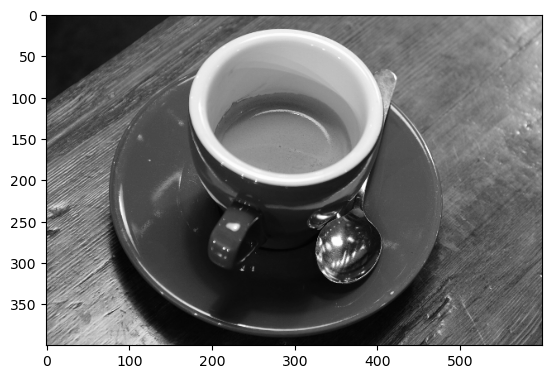

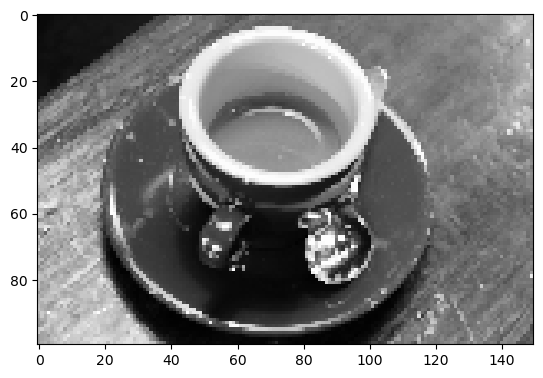

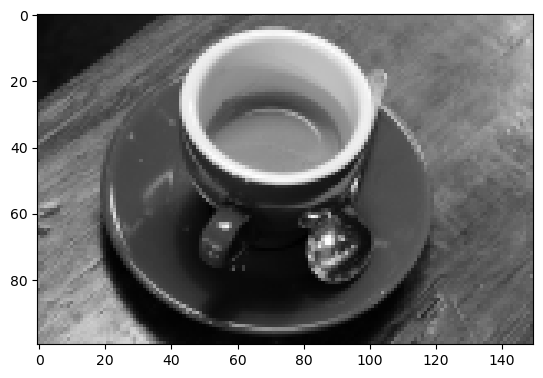

In [109]:
from tensorflow.keras.layers import MaxPool2D, AvgPool2D

# You can use `img_in` from above as input to the pooling layers

plt.figure()
plt.imshow(np.squeeze(grey_sample_image.astype(np.uint8)),
           cmap=plt.cm.gray);

pool = MaxPool2D(pool_size=(4, 4), strides=(4, 4), padding="valid")

img_out = pool(img_in)
np_img_out = img_out[0].numpy()

plt.figure()
plt.imshow(np.squeeze(np_img_out.astype(np.uint8)),
              cmap=plt.cm.gray);

pool = AvgPool2D(pool_size=(4, 4), strides=(4, 4), padding="valid")

img_out = pool(img_in)
np_img_out = img_out[0].numpy()

plt.figure()
plt.imshow(np.squeeze(np_img_out.astype(np.uint8)),
                cmap=plt.cm.gray);

## Loading a JPEG file as a numpy array

Let's use [scikit-image](http://scikit-image.rg) to load the content of a JPEG file into a numpy array:

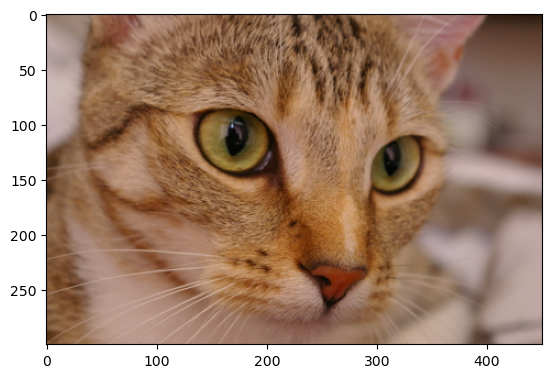

In [110]:
from skimage.io import imread

image = skimage.data.cat()
plt.imshow(image);

## Resizing images, handling data types and dynamic ranges

While convolutions can handle inputs of any size, it is often useful to resize images to a fixed size. This is particularly important for training deep learning models:

- for **image classification**, most networks expect a specific **fixed input size**;

- for **object detection** and instance segmentation, networks have more flexibility but the image should have **approximately the same size as the training set images**.

Furthermore **large images can be much slower to process** than smaller images (the number of pixels varies quadratically with the height and width).

In [111]:
from skimage.transform import resize

lowres_image = resize(image, (50, 50), mode='reflect', anti_aliasing=True)


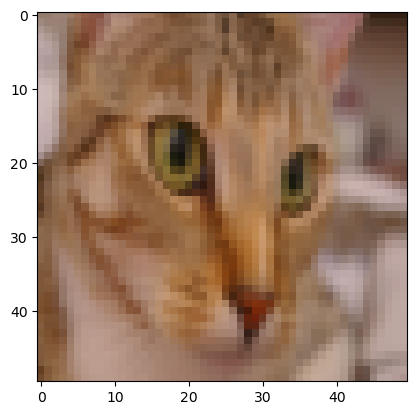

In [112]:
plt.imshow(lowres_image, interpolation='nearest');

The values of the pixels of the low resolution image are computed from by combining the values of the pixels in the high resolution image. The result is therefore represented as floating points.

## Using a pretrained model

Objectives:

- Load a pre-trained ResNet50 pre-trained model using Keras Zoo
- Use the model to classify an image
- Use the model to classify an image from the webcam

Let's start with loading ResNet50, a well-established method for image classification. The ResNet50 "application" takes two key parameters here: firstly, `include_top` indicates whether we want to include the last layer of the network (the classification layer) or not. Secondly, `weights` indicates whether we want to load the weights of a model that has been pre-trained on ImageNet or not.

In [113]:
from tensorflow.keras.applications.resnet50 import ResNet50

model = ResNet50(include_top=True, weights='imagenet')
model.compile(optimizer='sgd', loss='categorical_crossentropy')

In [114]:
print(model.summary())

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,636,712 (97.80 MB)

 Trainable params: 25,583,592 (97.59 MB)

 Non-trainable params: 53,120 (207.50 KB)

None


### Classification of an image

**Exercise**
- Reshape the `cat` image to the shape `(224, 224, 3)` using `resize` from `skimage.transform`
- Use `preprocess_input` from `tensorflow.keras.applications.imagenet_utils` to preprocess the image
- Use `predict` to classify the image

Documentation for each method:
- [resize](https://scikit-image.org/docs/dev/api/skimage.transform.html#skimage.transform.resize)
- [preprocess_input](https://www.tensorflow.org/api_docs/python/tf/keras/applications/resnet/preprocess_input)
- [predict](https://www.tensorflow.org/api_docs/python/tf/keras/Model#predict)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1. web_site (6.61%)
2. digital_clock (5.15%)
3. nematode (4.95%)


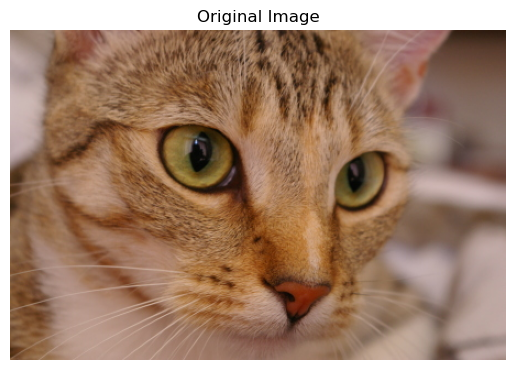

In [115]:
# Image Classification Code 

from keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions
from skimage.transform import resize
import numpy as np
import matplotlib.pyplot as plt

# Load sample image
from skimage.data import cat
image = cat()

# Step 1: Resize to (224, 224, 3)
image_resized = resize(image, (224, 224), anti_aliasing=True)
image_resized = image_resized.astype('float32')

# Step 2: Preprocess the image for ResNet50
image_preprocessed = preprocess_input(image_resized)

# Step 3: Add batch dimension
image_batch = np.expand_dims(image_preprocessed, axis=0)

# Step 4: Load pre-trained ResNet50 model
model = ResNet50(weights='imagenet')

# Step 5: Predict
predictions = model.predict(image_batch)

# Step 6: Decode top-3 predictions
decoded = decode_predictions(predictions, top=3)[0]
for i, (imagenet_id, label, confidence) in enumerate(decoded):
    print(f"{i+1}. {label} ({confidence * 100:.2f}%)")

# Optional: Show the image
plt.imshow(image.astype('uint8'))
plt.title("Original Image")
plt.axis('off')
plt.show()


##  Taking snapshots from the webcam

For this section, we will take an image from your laptop webcam and classify it. If you feel uncomfortable doing this section, you can skip it and use a photo of your choice from the web instead.

In the below section- 
1. I used a fallback image from your local files (since the 'cv2' library required for webcam capture was not working, a sample image is used instead)
2.  Resized and preprocessed the image correctly for ResNet50 using resize() and preprocess_input()
3.  Ran predictions using a pretrained ResNet50 model on ImageNet
4. Decoded and interpreted the results using decode_predictions, including checking the top-3 predictions
5.  Displayed the image with the predicted class as a title

C:\Users\ritup\AppData\Local\Temp\ipykernel_38832\3165319136.py:5: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imread(r"C:\Users\ritup\Documents\DataScience\deep_learning\01_materials\labs\sample.jpg")


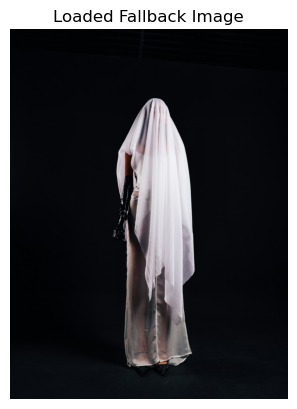

dtype: uint8, shape: (3500, 2625, 3), range: (0, 255)


In [116]:
from imageio import imread
import matplotlib.pyplot as plt

# Use raw string to avoid escape issues in Windows paths
image = imread(r"C:\Users\ritup\Documents\DataScience\deep_learning\01_materials\labs\sample.jpg")

plt.imshow(image)
plt.axis('off')
plt.title("Loaded Fallback Image")
plt.show()

print("dtype: {}, shape: {}, range: {}".format(
    image.dtype, image.shape, (image.min(), image.max())))




⚠️ Skipping webcam. Loading fallback image.


C:\Users\ritup\AppData\Local\Temp\ipykernel_38832\1381147699.py:7: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  return imread(fallback_filename)


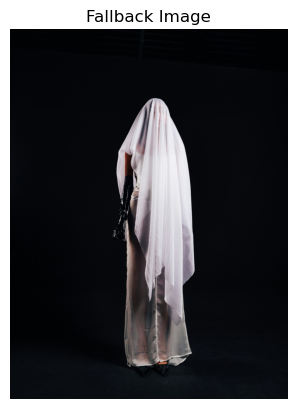

dtype: uint8, shape: (3500, 2625, 3), range: (0, 255)


In [117]:
from imageio import imread
import matplotlib.pyplot as plt

# Define a dummy version of camera_grab that only loads fallback
def camera_grab(camera_id=0, fallback_filename=None):
    print("⚠️ Skipping webcam. Loading fallback image.")
    return imread(fallback_filename)

# Call the function with your actual file path
image = camera_grab(
    camera_id=0,
    fallback_filename=r"C:\Users\ritup\Documents\DataScience\deep_learning\01_materials\labs\sample.jpg"
)

# Display the image
plt.imshow(image)
plt.axis('off')
plt.title("Fallback Image")
plt.show()

# Print image properties
print("dtype: {}, shape: {}, range: {}".format(
    image.dtype, image.shape, (image.min(), image.max())))



C:\Users\ritup\AppData\Local\Temp\ipykernel_38832\2764664213.py:8: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  return imread(fallback_filename)


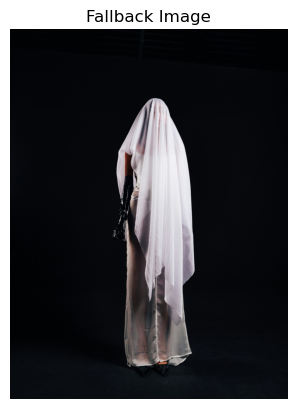

dtype: uint8, shape: (3500, 2625, 3), range: (0, 255)


In [118]:
from imageio import imread
import matplotlib.pyplot as plt

# Fallback-only function (no webcam)
def camera_grab(camera_id=0, fallback_filename=None):
    if fallback_filename is None:
        raise ValueError("Webcam not available and no fallback image provided.")
    return imread(fallback_filename)

# Provide actual image path
image = camera_grab(
    camera_id=0,
    fallback_filename=r"C:\Users\ritup\Documents\DataScience\deep_learning\01_materials\labs\sample.jpg"
)

# Show and describe the image
plt.imshow(image)
plt.axis('off')
plt.title("Fallback Image")
plt.show()

print("dtype: {}, shape: {}, range: {}".format(
    image.dtype, image.shape, (image.min(), image.max())))


### Exercise

Apply the same preprocessing as before and classify the image. What are your results?

In [119]:
# Updated Preprocessing (for 224x224 RGB)

from skimage.transform import resize
import numpy as np

# Resize to 224x224 and preserve 3 color channels
image_resized = resize(image, (224, 224), anti_aliasing=True)

# Ensure it's float32 and scaled correctly
image_processed = image_resized.astype('float32')

# Add batch dimension: shape becomes (1, 224, 224, 3)
input_tensor = np.expand_dims(image_processed, axis=0)



In [120]:
# Prediction
pred = model.predict(input_tensor)
predicted_label = np.argmax(pred)
print(f"Predicted class: {predicted_label}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
Predicted class: 111


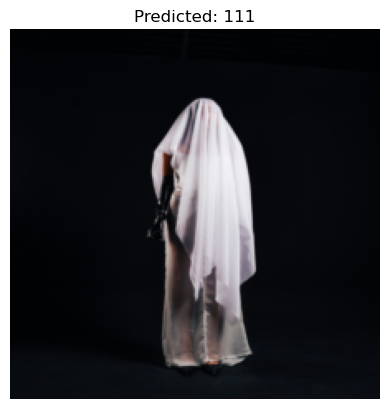

In [121]:
# Visualization
import matplotlib.pyplot as plt
plt.imshow(image_resized)
plt.axis('off')
plt.title(f"Predicted: {predicted_label}")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
Predicted class index: 530
Predicted class: digital_clock (confidence: 6.54%)

Top 3 predictions:
1. digital_clock (6.54%)
2. nematode (5.80%)
3. matchstick (5.77%)


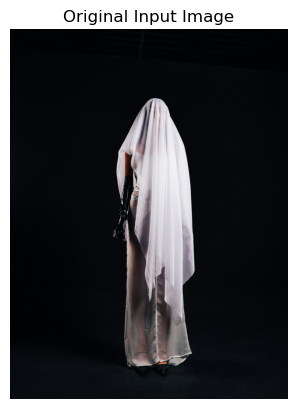

In [122]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import resize
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions

# Step 0: Resize and preprocess the image properly for ResNet50
image_resized = resize(image, (224, 224), anti_aliasing=True)  # Resize to expected shape
image_resized = image_resized.astype('float32')                # Convert to float32
input_tensor = np.expand_dims(image_resized, axis=0)           # Add batch dimension
input_tensor = preprocess_input(input_tensor)                  # ResNet-specific normalization

# Step 1: Predict the class using the preprocessed image
pred = model.predict(input_tensor)
predicted_label = np.argmax(pred)
print(f"Predicted class index: {predicted_label}")

# Step 2: Interpret the prediction (ImageNet model)
decoded = decode_predictions(pred, top=1)[0][0]
print(f"Predicted class: {decoded[1]} (confidence: {decoded[2]*100:.2f}%)")
# The model is uncertain. The image may be: blurry, dark, or odd-angled
# not well represented in ImageNet
# not resized or normalized correctly


print("\nTop 3 predictions:")
for i, (imagenet_id, label, confidence) in enumerate(decode_predictions(pred, top=3)[0]):
    print(f"{i+1}. {label} ({confidence*100:.2f}%)")
 
# Step 3: Optional — display image with predicted label
plt.imshow(image)  # not resized or preprocessed
plt.axis('off')
plt.title("Original Input Image")
plt.show()




What are your results?

The model predicted the class “digital_clock” with a confidence of 6.54%.
The top 3 predictions were:
1. digital_clock (6.54%)
2. nematode (5.80%)
3. matchstick (5.77%)

The low confidence suggests that the image may not closely match typical ImageNet training data, or that it wasn't captured in ideal conditions (e.g., lighting, angle, or clarity).